**Lab 1 – Real-Time Rotational Dynamics & Edge-AI Payload Safety System**


**Workflow**

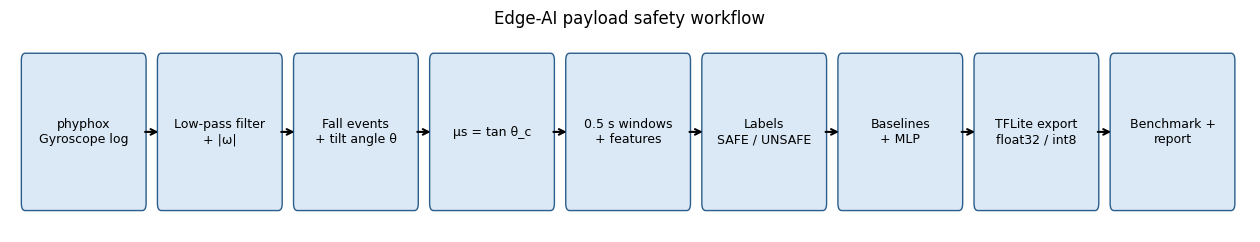

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

steps = ["phyphox\nGyroscope log", "Low-pass filter\n+ |ω|", "Fall events\n+ tilt angle θ", "μs = tan θ_c",
         "0.5 s windows\n+ features", "Labels\nSAFE / UNSAFE", "Baselines\n+ MLP", "TFLite export\nfloat32 / int8", "Benchmark +\nreport"]
fig, ax = plt.subplots(figsize=(16, 2.6))
ax.axis("off")
w, gap = 1.55, 0.25
for i, s in enumerate(steps):
    x = i * (w + gap)
    ax.add_patch(FancyBboxPatch((x, 0), w, 1, boxstyle="round,pad=0.05", fc="#dbe9f6", ec="#2b5d8a"))
    ax.text(x + w/2, 0.5, s, ha="center", va="center", fontsize=9)
    if i < len(steps) - 1:
        ax.annotate("", xy=(x + w + gap, 0.5), xytext=(x + w, 0.5), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.set_xlim(-0.2, len(steps) * (w + gap)); ax.set_ylim(-0.2, 1.2)
plt.title("Edge-AI payload safety workflow")
plt.savefig("workflow_lab1.png", dpi=150, bbox_inches="tight")
plt.show()

**Setup**

In [2]:
import os, time, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score, roc_curve, roc_auc_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

try:
    from ai_edge_litert.interpreter import Interpreter
except ImportError:
    Interpreter = tf.lite.Interpreter

np.random.seed(42); tf.random.set_seed(42)
print("TensorFlow", tf.__version__)

from scipy.signal import butter, filtfilt

RAW_PATH   = "phyphox_gyro_data.csv"
LABEL_PATH = "fall_detection_dataset.csv"
RADIUS_M   = 0.07
WIN_S, STEP_S = 0.5, 0.25
CUTOFF_HZ  = 5
G = 9.81

TensorFlow 2.20.0


**Load raw phyphox data and labels**

In [3]:
for need in [RAW_PATH, LABEL_PATH]:
    if not os.path.exists(need):
        try:
            from google.colab import files
            print("Upload", need); up = files.upload()
            for k in up: os.rename(k, need)
        except Exception as e:
            print("Upload failed:", e)

raw = pd.read_csv(RAW_PATH, sep=None, engine="python")
raw = raw.iloc[:, :4]; raw.columns = ["t", "wx", "wy", "wz"]
raw = raw.apply(pd.to_numeric, errors="coerce").dropna().sort_values("t").drop_duplicates("t").reset_index(drop=True)
lab_df = pd.read_csv(LABEL_PATH)

t = raw.t.values
FS = 1 / np.median(np.diff(t))
print(f"Raw samples: {len(raw)} | duration: {t[-1]-t[0]:.1f} s | fs ≈ {FS:.0f} Hz")
print("Labelled windows:", len(lab_df), "| SAFE/UNSAFE:", lab_df.label.value_counts().sort_index().tolist())
raw.head()

Upload phyphox_gyro_data.csv


Saving Raw Data.csv to Raw Data.csv
Upload fall_detection_dataset.csv


Saving fall_detection_dataset.csv to fall_detection_dataset.csv
Raw samples: 35846 | duration: 71.7 s | fs ≈ 500 Hz
Labelled windows: 285 | SAFE/UNSAFE: [207, 78]


,t,wx,wy,wz
0,0.011484,-0.073304,0.118508,0.032376
1,0.013483,-0.073304,0.118508,0.032376
2,0.015483,-0.073304,0.118508,0.032376
3,0.017482,-0.073304,0.118508,0.032376
4,0.019482,-0.073304,0.118508,0.032376


**Preprocessing – low-pass filter and |ω|**

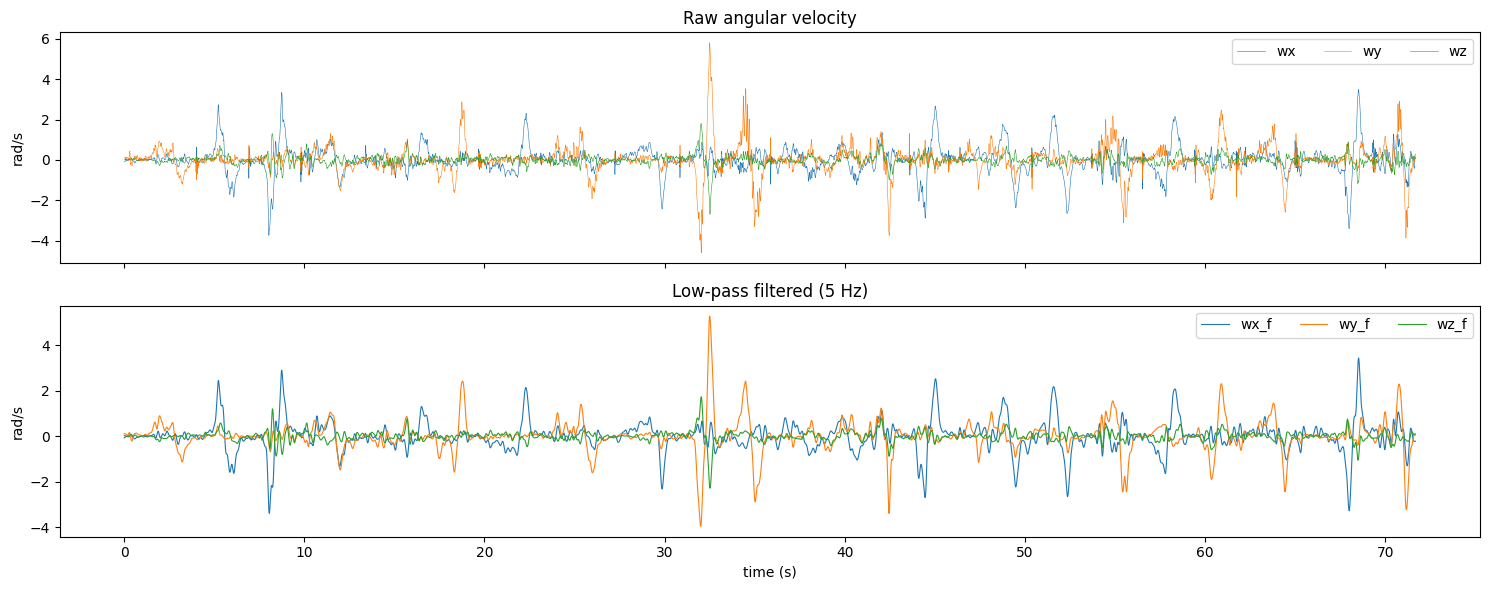

Mean |wz| = 0.149 rad/s vs mean tilt rate = 0.65 rad/s


In [4]:
b, a = butter(4, CUTOFF_HZ / (FS / 2), btype="low")
for c in ["wx", "wy", "wz"]:
    raw[c + "_f"] = filtfilt(b, a, raw[c])
raw["wmag"]  = np.sqrt(raw.wx**2 + raw.wy**2 + raw.wz**2)
raw["wtilt"] = np.sqrt(raw.wx_f**2 + raw.wy_f**2)

fig, axs = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
for c in ["wx", "wy", "wz"]:
    axs[0].plot(t, raw[c], lw=0.4, label=c)
axs[0].set_ylabel("rad/s"); axs[0].legend(ncol=3); axs[0].set_title("Raw angular velocity")
for c in ["wx_f", "wy_f", "wz_f"]:
    axs[1].plot(t, raw[c], lw=0.8, label=c)
axs[1].set_ylabel("rad/s"); axs[1].set_xlabel("time (s)"); axs[1].legend(ncol=3); axs[1].set_title(f"Low-pass filtered ({CUTOFF_HZ} Hz)")
plt.tight_layout(); plt.show()
print("Mean |wz| =", round(raw.wz.abs().mean(), 3), "rad/s vs mean tilt rate =", round(raw.wtilt.mean(), 3), "rad/s")

**Windowing and feature extraction**

In [5]:
def win_feats(v):
    return [v.mean(), v.var(), v.std(), v.min(), v.max(), np.ptp(v), np.sqrt(np.mean(v**2)), np.mean(np.abs(np.diff(v)))]
fnames = ["mean", "variance", "std", "min", "max", "range", "rms", "mean_abs_change"]

rows, win_start = [], []
s0 = t[0]
while s0 + WIN_S <= t[-1] + 1e-9 and len(rows) < len(lab_df):
    sel = (t >= s0) & (t < s0 + WIN_S)
    w = raw.loc[sel]
    rows.append(sum([win_feats(w[c].values) for c in ["wx", "wy", "wz", "wmag"]], []))
    win_start.append(s0); s0 += STEP_S

feature_cols = [f"{ax}_{f}" for ax in ["x", "y", "z", "mag"] for f in fnames]
df = pd.DataFrame(rows, columns=feature_cols)
df["label"] = lab_df.label.values[:len(df)]
df["t_start"] = win_start

print("Max |difference| vs provided x_mean:", np.abs(df.x_mean - lab_df.x_mean[:len(df)]).max())
df.to_csv("features_xyz_labeled.csv", index=False)
print(df.shape); df.head()

Max |difference| vs provided x_mean: 2.220446049250313e-16
(285, 34)


,x_mean,x_variance,x_std,x_min,x_max,x_range,x_rms,x_mean_abs_change,y_mean,y_variance,...,mag_mean,mag_variance,mag_std,mag_min,mag_max,mag_range,mag_rms,mag_mean_abs_change,label,t_start
0,-0.012981,0.001018,0.031913,-0.073304,0.055589,0.128893,0.034452,0.002522,0.022726,0.024324,...,0.144590,0.007397,0.086008,0.030555,0.442529,0.411973,0.168237,0.007980,0,0.011484
1,-0.036918,0.002425,0.049246,-0.153327,0.055589,0.208916,0.061548,0.002740,0.044845,0.027222,...,0.174360,0.005402,0.073497,0.032743,0.442529,0.409786,0.189218,0.008635,0,0.261484
2,-0.039257,0.002387,0.048858,-0.153327,0.040928,0.194255,0.062675,0.002600,0.083197,0.003861,...,0.113853,0.002866,0.053533,0.009264,0.230116,0.220852,0.125810,0.005340,0,0.511484
3,-0.012281,0.000751,0.027407,-0.048869,0.040928,0.089797,0.030032,0.002416,0.046516,0.003504,...,0.078690,0.001226,0.035019,0.009264,0.194338,0.185074,0.086130,0.004883,0,0.761484
4,-0.005630,0.000814,0.028529,-0.048869,0.049480,0.098349,0.029079,0.002176,0.075325,0.005764,...,0.101265,0.002620,0.051183,0.014963,0.219880,0.204917,0.113465,0.005429,0,1.011484


**Fall events and coefficient of static friction**

The phone is tilted until the payload slides. At the moment it slips, the slope angle θ_c satisfies μs = tan θ_c.
For each UNSAFE event, θ is found by integrating the filtered ωx and ωy from the last rest point before the event up to just before the slip jolt. Resetting at each rest point stops gyro drift from building up across the recording.

In [6]:
events, i, L = [], 0, df.label.values
while i < len(L):
    if L[i] == 1:
        j = i
        while j + 1 < len(L) and L[j + 1] == 1: j += 1
        events.append((df.t_start[i], df.t_start[j] + WIN_S)); i = j + 1
    else:
        i += 1

rest_n = int(0.2 * FS)
ev_rows = []
for ts, te in events:
    sel = np.where((t >= ts) & (t <= te))[0]
    k_peak = sel[np.argmax(raw.wmag.values[sel])]
    k_end = np.searchsorted(t, t[k_peak] - 0.1)
    k_lo = np.searchsorted(t, ts - 4)
    k_rest = k_lo
    for q in range(np.searchsorted(t, ts), k_lo + rest_n, -1):
        if raw.wtilt.values[q - rest_n:q].max() < 0.2:
            k_rest = q; break
    th_x = np.trapezoid(raw.wx_f.values[k_rest:k_end], t[k_rest:k_end])
    th_y = np.trapezoid(raw.wy_f.values[k_rest:k_end], t[k_rest:k_end])
    theta = np.hypot(th_x, th_y)
    w_c = raw.wtilt.values[k_end - int(0.1 * FS):k_end].mean()
    ev_rows.append([ts, t[k_peak], np.degrees(theta), np.tan(theta), w_c, raw.wmag.values[k_peak]])

ev = pd.DataFrame(ev_rows, columns=["event_start", "slip_time", "theta_deg", "mu_s", "omega_before_slip", "peak_omega"]).round(3)

q1, q3 = ev.theta_deg.quantile([0.25, 0.75]); iqr = q3 - q1
ok = ev.theta_deg.between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
theta_c = ev.loc[ok, "theta_deg"].median()
mu_s = np.tan(np.radians(theta_c))
mu_s_std = ev.loc[ok, "mu_s"].std()
omega_c = ev.loc[ok, "omega_before_slip"].median()
mu_rot = omega_c**2 * RADIUS_M / G

print(f"Fall events detected           : {len(ev)} ({(~ok).sum()} outliers removed)")
print(f"Critical tilt angle θ_c        : {theta_c:.1f}°")
print(f"μs = tan θ_c                   : {mu_s:.3f}  (± {mu_s_std:.3f} std across events)")
print(f"Angular rate just before slip  : {omega_c:.3f} rad/s")
print(f"Centripetal check ω²r/g        : {mu_rot:.4f}  (≪ μs → slip is caused by tilt, not rotation)")
ev

Fall events detected           : 20 (4 outliers removed)
Critical tilt angle θ_c        : 37.7°
μs = tan θ_c                   : 0.774  (± 0.256 std across events)
Angular rate just before slip  : 1.135 rad/s
Centripetal check ω²r/g        : 0.0066  (≪ μs → slip is caused by tilt, not rotation)


,event_start,slip_time,theta_deg,mu_s,omega_before_slip,peak_omega
0,2.511,3.240,23.205,0.429,0.830,1.211
1,5.261,5.263,12.749,0.226,1.102,2.405
2,8.011,8.040,5.847,0.102,0.621,3.754
3,11.511,12.001,42.184,0.906,1.098,2.018
4,18.261,18.753,34.867,0.697,0.904,2.877
5,21.761,22.321,36.234,0.733,1.298,2.328
6,25.511,25.977,39.344,0.820,1.063,1.979
7,29.511,29.867,36.167,0.731,0.772,2.463
8,32.011,32.511,64.367,2.084,1.692,6.305
9,34.511,34.513,36.585,0.742,1.867,3.514


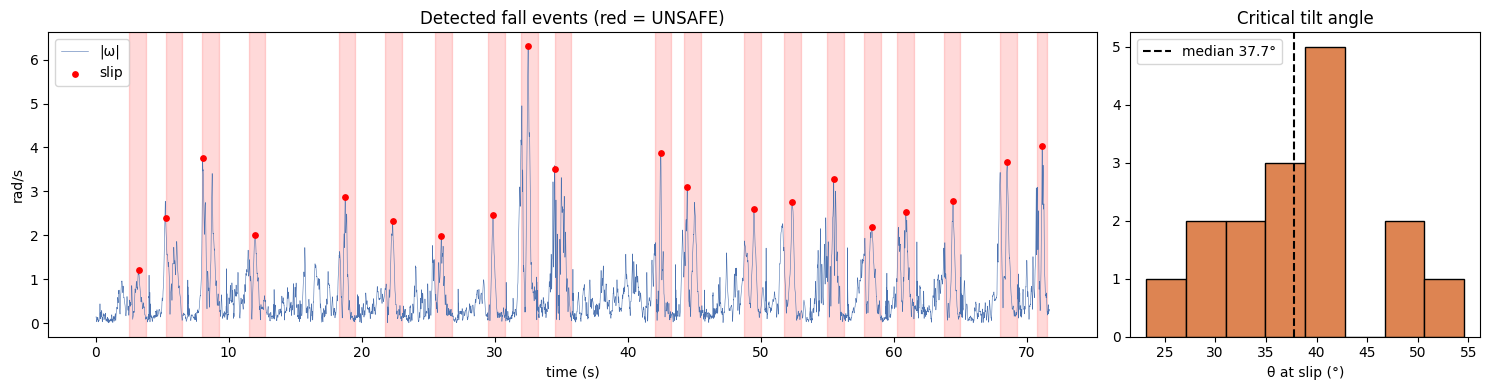

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4), gridspec_kw={"width_ratios": [3, 1]})
axs[0].plot(t, raw.wmag, lw=0.4, color="#4c72b0", label="|ω|")
for ts, te in events:
    axs[0].axvspan(ts, te, color="r", alpha=0.15)
axs[0].scatter(ev.slip_time, ev.peak_omega, color="r", s=15, zorder=3, label="slip")
axs[0].set_xlabel("time (s)"); axs[0].set_ylabel("rad/s"); axs[0].legend(); axs[0].set_title("Detected fall events (red = UNSAFE)")
axs[1].hist(ev.loc[ok, "theta_deg"], bins=8, color="#dd8452", edgecolor="k")
axs[1].axvline(theta_c, color="k", ls="--", label=f"median {theta_c:.1f}°")
axs[1].set_xlabel("θ at slip (°)"); axs[1].legend(); axs[1].set_title("Critical tilt angle")
plt.tight_layout(); plt.savefig("fall_events.png", dpi=150); plt.show()

**Feature analysis and classification threshold**

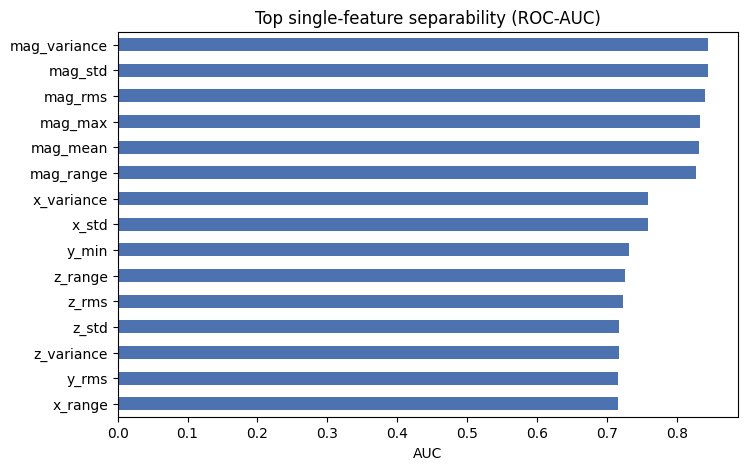

Rule threshold on mag_rms: 0.839 rad/s (TPR=0.81, FPR=0.19)


In [8]:
auc = {c: roc_auc_score(df.label, df[c]) for c in feature_cols}
auc = pd.Series({c: max(v, 1 - v) for c, v in auc.items()}).sort_values(ascending=False)
auc.head(15).plot.barh(figsize=(8, 5), color="#4c72b0"); plt.gca().invert_yaxis()
plt.title("Top single-feature separability (ROC-AUC)"); plt.xlabel("AUC"); plt.show()

fpr, tpr, thr = roc_curve(df.label, df.mag_rms)
j = np.argmax(tpr - fpr)
omega_thr = float(thr[j])
print(f"Rule threshold on mag_rms: {omega_thr:.3f} rad/s (TPR={tpr[j]:.2f}, FPR={fpr[j]:.2f})")

**Train / test split (time-based) and normalisation**

In [9]:
X = df[feature_cols].values.astype(np.float32)
y = df.label.values
cut = int(0.75 * len(df))
X_tr, X_te, y_tr, y_te = X[:cut], X[cut:], y[:cut], y[cut:]
print(f"Split at t = {df.t_start[cut]:.1f} s | train UNSAFE: {y_tr.sum()} / {len(y_tr)} | test UNSAFE: {y_te.sum()} / {len(y_te)}")
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr).astype(np.float32)
X_te_s = scaler.transform(X_te).astype(np.float32)
print("Train:", X_tr_s.shape, "Test:", X_te_s.shape, "| features:", len(feature_cols))

Split at t = 53.3 s | train UNSAFE: 56 / 213 | test UNSAFE: 22 / 72
Train: (213, 32) Test: (72, 32) | features: 32


**Baseline models**

In [10]:
def scores(y_true, p):
    return {"Accuracy": accuracy_score(y_true, p), "Precision": precision_score(y_true, p, zero_division=0),
            "Recall": recall_score(y_true, p), "F1": f1_score(y_true, p)}

results = {}
results["Threshold rule (mag_rms ≥ thr)"] = (X_te[:, feature_cols.index("mag_rms")] >= omega_thr).astype(int)

lr = LogisticRegression(max_iter=2000, class_weight="balanced").fit(X_tr_s, y_tr)
results["Logistic Regression"] = lr.predict(X_te_s)

dt = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42).fit(X_tr_s, y_tr)
results["Decision Tree (d=4)"] = dt.predict(X_te_s)

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42).fit(X_tr_s, y_tr)
results["Random Forest"] = rf.predict(X_te_s)

pd.DataFrame({k: scores(y_te, p) for k, p in results.items()}).T.round(3)

,Accuracy,Precision,Recall,F1
Threshold rule (mag_rms ≥ thr),0.778,0.594,0.864,0.704
Logistic Regression,0.819,0.696,0.727,0.711
Decision Tree (d=4),0.792,0.630,0.773,0.694
Random Forest,0.792,0.640,0.727,0.681


**TinyML MLP**

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673 (2.63 KB)

 Trainable params: 673 (2.63 KB)

 Non-trainable params: 0 (0.00 B)

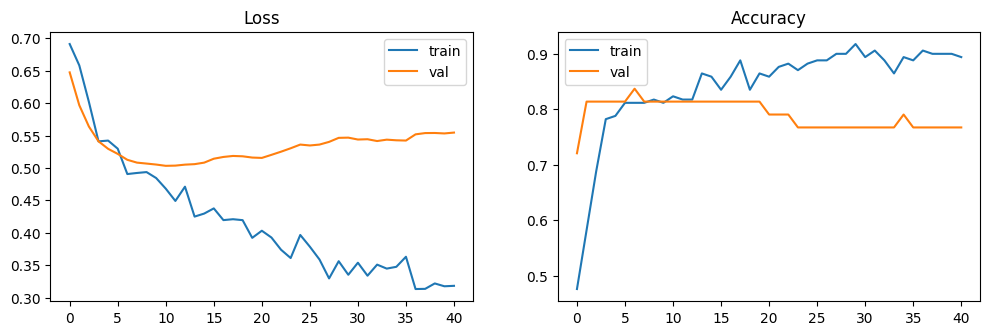

              precision    recall  f1-score   support

        SAFE       0.95      0.72      0.82        50
      UNSAFE       0.59      0.91      0.71        22

    accuracy                           0.78        72
   macro avg       0.77      0.81      0.77        72
weighted avg       0.84      0.78      0.79        72



In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_tr_s.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

cw = {0: len(y_tr) / (2 * (y_tr == 0).sum()), 1: len(y_tr) / (2 * (y_tr == 1).sum())}
hist = model.fit(X_tr_s, y_tr, validation_split=0.2, epochs=300, batch_size=16, class_weight=cw, verbose=0,
                 callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True)])

fig, axs = plt.subplots(1, 2, figsize=(12, 3.5))
axs[0].plot(hist.history["loss"], label="train"); axs[0].plot(hist.history["val_loss"], label="val"); axs[0].set_title("Loss"); axs[0].legend()
axs[1].plot(hist.history["accuracy"], label="train"); axs[1].plot(hist.history["val_accuracy"], label="val"); axs[1].set_title("Accuracy"); axs[1].legend()
plt.show()

p_keras = (model.predict(X_te_s, verbose=0).ravel() >= 0.5).astype(int)
results["Keras MLP (float32)"] = p_keras
print(classification_report(y_te, p_keras, target_names=["SAFE", "UNSAFE"]))
model.save("payload_safety_mlp.keras")

**TFLite conversion – float32 and full-integer int8**

In [12]:
def rep_data():
    for i in range(len(X_tr_s)):
        yield [X_tr_s[i:i+1]]

conv = tf.lite.TFLiteConverter.from_keras_model(model)
tfl_f32 = conv.convert()
open("payload_safety_f32.tflite", "wb").write(tfl_f32)

conv = tf.lite.TFLiteConverter.from_keras_model(model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.representative_dataset = rep_data
conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv.inference_input_type = tf.int8
conv.inference_output_type = tf.int8
tfl_int8 = conv.convert()
open("payload_safety_int8.tflite", "wb").write(tfl_int8)

for f in ["payload_safety_mlp.keras", "payload_safety_f32.tflite", "payload_safety_int8.tflite"]:
    print(f"{f:30s} {os.path.getsize(f)/1024:8.2f} KB")

Saved artifact at '/tmp/tmpgbbsk98p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  131989929040528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131989929040336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131989929044752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131989929048976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131989929048592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131989929044560: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved artifact at '/tmp/tmp5xi1mw90'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  131989929040528: TensorSpec(

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


**Edge inference and benchmarking**

In [13]:
def run_tflite(path, Xs, reps=3):
    itp = Interpreter(model_path=path, num_threads=1); itp.allocate_tensors()
    inp, out = itp.get_input_details()[0], itp.get_output_details()[0]
    preds, times = [], []
    for x in Xs:
        x = x[None, :]
        if inp["dtype"] == np.int8:
            s, z = inp["quantization"]; x = np.round(x / s + z).clip(-128, 127).astype(np.int8)
        itp.set_tensor(inp["index"], x)
        best = 1e18
        for _ in range(reps):
            t0 = time.perf_counter_ns(); itp.invoke(); best = min(best, time.perf_counter_ns() - t0)
        times.append(best / 1e3)
        o = itp.get_tensor(out["index"]).astype(np.float32)
        if out["dtype"] == np.int8:
            s, z = out["quantization"]; o = (o - z) * s
        preds.append(int(o.ravel()[0] >= 0.5))
    return np.array(preds), float(np.mean(times))

bench = []
t0 = time.perf_counter()
for x in X_te_s: model(x[None, :], training=False)
keras_us = (time.perf_counter() - t0) / len(X_te_s) * 1e6
bench.append(["Keras MLP", "float32", os.path.getsize("payload_safety_mlp.keras")/1024, *scores(y_te, p_keras).values(), keras_us])

for name, path, dt_ in [("TFLite float32", "payload_safety_f32.tflite", "float32"), ("TFLite int8 (PTQ)", "payload_safety_int8.tflite", "int8")]:
    p, us = run_tflite(path, X_te_s)
    results[name] = p
    bench.append([name, dt_, os.path.getsize(path)/1024, *scores(y_te, p).values(), us])

bench_df = pd.DataFrame(bench, columns=["Model", "Type", "Size (KB)", "Accuracy", "Precision", "Recall", "F1", "Latency (µs)"]).round(3)
bench_df.to_csv("benchmark_lab1.csv", index=False)
bench_df

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,Model,Type,Size (KB),Accuracy,Precision,Recall,F1,Latency (µs)
0,Keras MLP,float32,34.926,0.778,0.588,0.909,0.714,3320.683
1,TFLite float32,float32,4.645,0.778,0.588,0.909,0.714,1.294
2,TFLite int8 (PTQ),int8,3.609,0.778,0.588,0.909,0.714,1.268


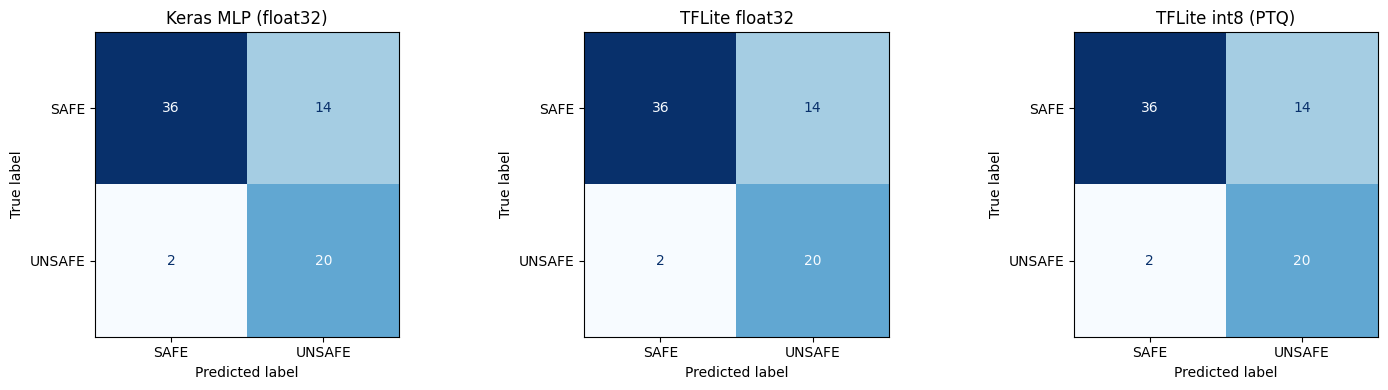

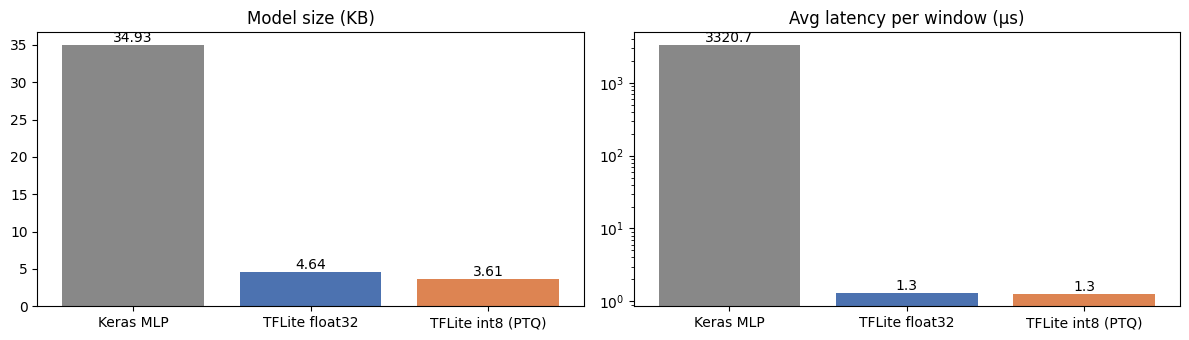

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axs, ["Keras MLP (float32)", "TFLite float32", "TFLite int8 (PTQ)"]):
    ConfusionMatrixDisplay(confusion_matrix(y_te, results[k]), display_labels=["SAFE", "UNSAFE"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(k)
plt.tight_layout(); plt.savefig("confusion_matrices_lab1.png", dpi=150); plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 3.5))
cols = ["#888", "#4c72b0", "#dd8452"]
b = axs[0].bar(bench_df.Model, bench_df["Size (KB)"], color=cols); axs[0].bar_label(b, fmt="%.2f"); axs[0].set_title("Model size (KB)")
b = axs[1].bar(bench_df.Model, bench_df["Latency (µs)"], color=cols); axs[1].bar_label(b, fmt="%.1f"); axs[1].set_title("Avg latency per window (µs)")
axs[1].set_yscale("log")
plt.tight_layout(); plt.show()

**Export int8 model as C array (microcontroller)**

In [15]:
hexs = ", ".join(f"0x{b:02x}" for b in tfl_int8)
open("payload_model_int8.h", "w").write(
    f"// int8 payload safety model\nalignas(16) const unsigned char payload_model[] = {{ {hexs} }};\nconst unsigned int payload_model_len = {len(tfl_int8)};\n")
itp = Interpreter(model_path="payload_safety_int8.tflite"); itp.allocate_tensors()
print("int8 input quant (scale, zero_point):", itp.get_input_details()[0]["quantization"])
pd.DataFrame({"feature": feature_cols, "mean": scaler.mean_, "std": scaler.scale_}).to_csv("scaler_params.csv", index=False)
print("Saved payload_model_int8.h and scaler_params.csv (needed on-device for normalisation)")

int8 input quant (scale, zero_point): (0.07093445956707001, -27)
Saved payload_model_int8.h and scaler_params.csv (needed on-device for normalisation)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


**Lab report summary**

In [16]:
cm = confusion_matrix(y_te, results["TFLite int8 (PTQ)"])
f32_kb = os.path.getsize("payload_safety_f32.tflite") / 1024
i8_kb = os.path.getsize("payload_safety_int8.tflite") / 1024
print("=" * 58)
print("LAB REPORT SUMMARY")
print("=" * 58)
print(f"Windows (SAFE / UNSAFE)        : {(y==0).sum()} / {(y==1).sum()}")
print(f"Fall events                    : {len(ev)}")
print(f"Critical tilt angle θ_c        : {theta_c:.1f}°")
print(f"μs = tan θ_c                   : {mu_s:.3f} ± {mu_s_std:.3f}")
print(f"Keras MLP accuracy / F1        : {accuracy_score(y_te, p_keras)*100:.2f} % / {f1_score(y_te, p_keras):.3f}")
print(f"int8 TFLite accuracy / F1      : {accuracy_score(y_te, results['TFLite int8 (PTQ)'])*100:.2f} % / {f1_score(y_te, results['TFLite int8 (PTQ)']):.3f}")
print(f"Confusion matrix (int8)        : TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")
print(f"TFLite float32 size            : {f32_kb:.2f} KB")
print(f"TFLite int8 size               : {i8_kb:.2f} KB  ({(1-i8_kb/f32_kb)*100:.1f}% smaller)")

LAB REPORT SUMMARY
Windows (SAFE / UNSAFE)        : 207 / 78
Fall events                    : 20
Critical tilt angle θ_c        : 37.7°
μs = tan θ_c                   : 0.774 ± 0.256
Keras MLP accuracy / F1        : 77.78 % / 0.714
int8 TFLite accuracy / F1      : 77.78 % / 0.714
Confusion matrix (int8)        : TN=36 FP=14 FN=2 TP=20
TFLite float32 size            : 4.64 KB
TFLite int8 size               : 3.61 KB  (22.3% smaller)


Observations:
- In this recording the payload slid because the phone was tilted. ωz stays small, and the centripetal term ω²r/g is far below μs, so the tilt method (μs = tan θ_c) is the one that applies.
- θ_c varies from event to event because of how fast the phone was tilted, integration drift, and where the payload sat. That is why the median of the events is reported.
- The split is time-based because the windows overlap, and a random split would give an optimistic score.
- Full-integer quantization makes the model smaller and lets it run on integer-only MCUs, and it loses little or no accuracy.
- In safety terms, missing an UNSAFE window (a false negative) costs more than a false alarm, so recall on UNSAFE is the key metric.

**Download deliverables**

In [17]:
out = [RAW_PATH, LABEL_PATH, "features_xyz_labeled.csv", "fall_events.png", "payload_safety_mlp.keras", "payload_safety_f32.tflite", "payload_safety_int8.tflite", "payload_model_int8.h",
       "scaler_params.csv", "benchmark_lab1.csv", "workflow_lab1.png", "confusion_matrices_lab1.png"]
with zipfile.ZipFile("lab1_deliverables.zip", "w") as z:
    for f in out:
        if os.path.exists(f): z.write(f)
print("Saved lab1_deliverables.zip")
try:
    from google.colab import files; files.download("lab1_deliverables.zip")
except Exception:
    pass

Saved lab1_deliverables.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>